# Local-Variance Gaussian Noise 1024 synthetic-image example

Gaussian noise with a spatially varying variance map. This notebook starts from the same synthetic 1024 x 1024 image, applies one AGFB noise model, and displays the clean image, noisy image, and residual.


## Setup

Import the model function and notebook helpers. The autoreload lines help Jupyter pick up local source edits without restarting the kernel.


In [1]:
# Imports and local reloads.
%load_ext autoreload
%autoreload 2

import time

import torch

from agfb_noise import add_local_variance
from agfb_noise.notebook import show_noise_preview, summarize_tensors, synthetic_1024_image

## Synthetic Image

Create the shared 1024 x 1024 synthetic input on CUDA when available.


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
seed = 123

clean = synthetic_1024_image(device=device)
clean.shape, clean.device, clean.dtype

(torch.Size([1, 1024, 1024]), device(type='cpu'), torch.float32)

## Apply Noise

Set the model parameters and corrupt the image.


In [3]:
yy, xx = torch.meshgrid(
    torch.linspace(-1.0, 1.0, clean.shape[-2], device=clean.device),
    torch.linspace(-1.0, 1.0, clean.shape[-1], device=clean.device),
    indexing="ij",
)
variance = (0.0002 + 0.004 * ((xx + 1.0) / 2.0) ** 2).unsqueeze(0)


def apply_model() -> torch.Tensor:
    return add_local_variance(clean, variance=variance, seed=seed, clamp=(0.0, 1.0))


noisy = apply_model()
delta = noisy - clean

## Summary

Report compact tensor statistics for the clean, noisy, and residual images.


In [4]:
summarize_tensors(
    {
        "clean": clean,
        "noisy": noisy,
        "delta": delta,
    }
)

[{'name': 'clean',
  'min': 0.11334408074617386,
  'q01': 0.1417168229818344,
  'mean': 0.48850709199905396,
  'q50': 0.5385441184043884,
  'q99': 0.8480556011199951,
  'max': 0.9545643329620361,
  'std': 0.18355251848697662},
 {'name': 'noisy',
  'min': 0.06952523440122604,
  'q01': 0.13590538501739502,
  'mean': 0.4884832501411438,
  'q50': 0.5300283432006836,
  'q99': 0.865729570388794,
  'max': 1.0,
  'std': 0.18766887485980988},
 {'name': 'delta',
  'min': -0.2937213182449341,
  'q01': -0.1057998389005661,
  'mean': -2.3852535377955064e-05,
  'q50': 2.136826515197754e-05,
  'q99': 0.1059778481721878,
  'max': 0.28829288482666016,
  'std': 0.03922179713845253}]

## Preview

The preview down-samples the 1024 image for display. The residual uses a blue-white-garnet diverging map.



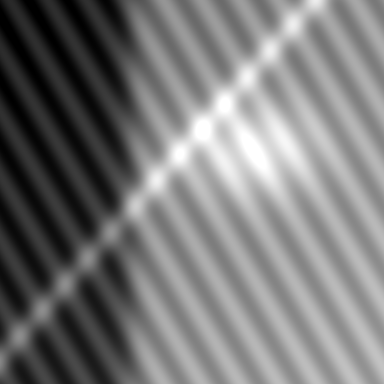
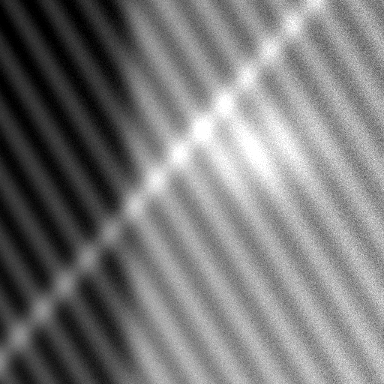
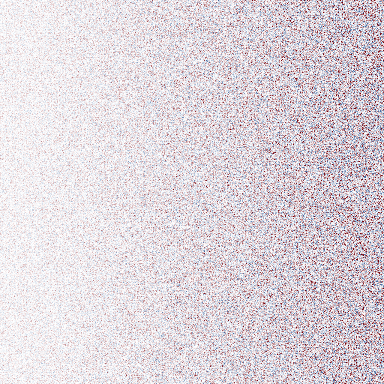


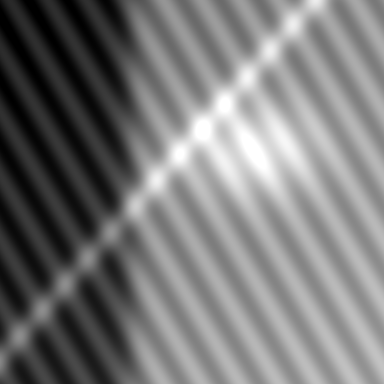
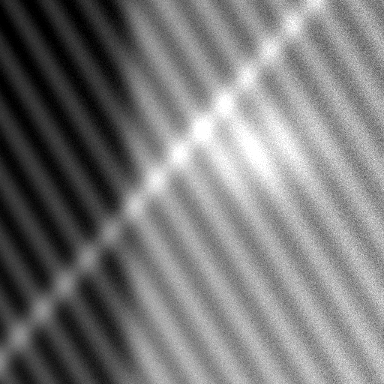
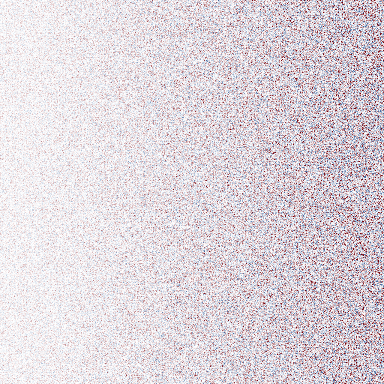

In [5]:
show_noise_preview(clean, noisy, title="Local-Variance Gaussian Noise")

## Timing

Time one hot-path model application on the selected device.


In [6]:
if clean.is_cuda:
    torch.cuda.synchronize()
start = time.perf_counter()
_ = apply_model()
if clean.is_cuda:
    torch.cuda.synchronize()
elapsed_ms = (time.perf_counter() - start) * 1000.0
elapsed_ms

13.958666939288378